# IKT215 Assignment 2: Parametric and Non-parametric Classification
**Student:** Gomery K. Wanjiru  
**Course:** IKT215

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, precision_recall_fscore_support

# Plot settings
plt.rcParams.update({
    'figure.dpi': 150,
    'figure.figsize': (9, 6),
    'font.size': 12,
    'font.family': 'serif'
})

## Load and Prepare the Wine Quality Dataset

In [2]:
# Load both red and white wine datasets
red = pd.read_csv('../../../data/raw/wine+quality/winequality-red.csv', sep=';')
white = pd.read_csv('../../../data/raw/wine+quality/winequality-white.csv', sep=';')
df = pd.concat([red, white], ignore_index=True)

# Binary label: good (quality >= 5) vs bad (quality < 5)
df['label'] = (df['quality'] >= 5).astype(int)

print(f"Total samples: {len(df)} ({len(red)} red + {len(white)} white)")
print(f"\nQuality distribution:")
print(df['quality'].value_counts().sort_index())
print(f"\nBinary label: Good={df['label'].sum()}, Bad={(df['label']==0).sum()}")
print(f"Class ratio: {df['label'].mean():.2%} good, {1-df['label'].mean():.2%} bad")

Total samples: 6497 (1599 red + 4898 white)

Quality distribution:
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64

Binary label: Good=6251, Bad=246
Class ratio: 96.21% good, 3.79% bad


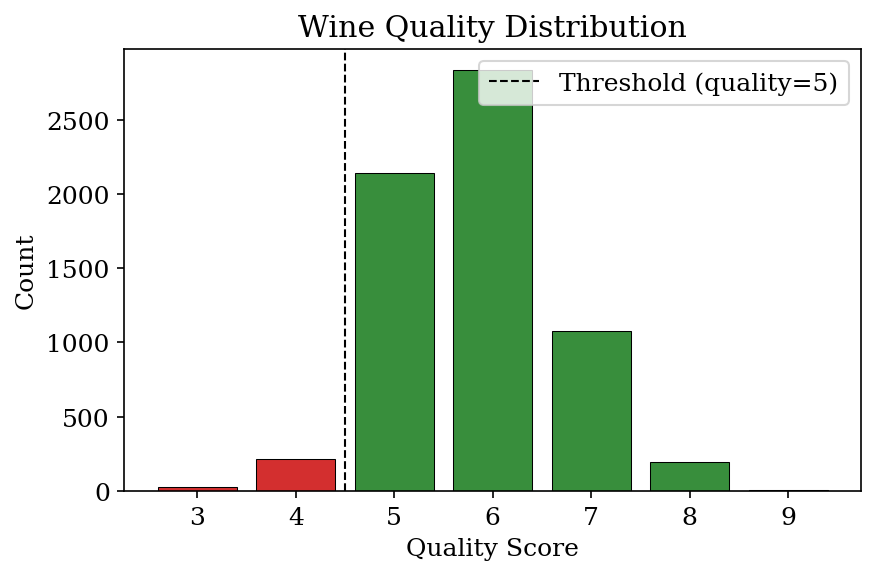

In [3]:
# Visualize the quality distribution
fig, ax = plt.subplots(figsize=(6, 4))
labels_unique, counts = np.unique(df['quality'], return_counts=True)
colors = ['#d32f2f' if q < 5 else '#388e3c' for q in labels_unique]
ax.bar(labels_unique, counts, color=colors, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Quality Score')
ax.set_ylabel('Count')
ax.set_title('Wine Quality Distribution')
ax.axvline(x=4.5, color='black', linestyle='--', linewidth=1, label='Threshold (quality=5)')
ax.legend()
plt.tight_layout()
plt.show()

## Feature Selection

I need to pick features that are:
1. Correlated with wine quality
2. Not too correlated with each other (to avoid redundancy)

In [4]:
numeric_cols = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 
                'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 
                'pH', 'sulphates', 'alcohol']

# Correlation with quality score
print("Correlation with quality (absolute value):")
corrs = df[numeric_cols].corrwith(df['quality']).abs().sort_values(ascending=False)
for feat, corr in corrs.items():
    print(f"  {feat:25s}: {corr:.4f}")

Correlation with quality (absolute value):
  alcohol                  : 0.4443
  density                  : 0.3059
  volatile acidity         : 0.2657
  chlorides                : 0.2007
  citric acid              : 0.0855
  fixed acidity            : 0.0767
  free sulfur dioxide      : 0.0555
  total sulfur dioxide     : 0.0414
  sulphates                : 0.0385
  residual sugar           : 0.0370
  pH                       : 0.0195


In [5]:
# Check inter-feature correlations to avoid picking redundant features
corr_matrix = df[numeric_cols].corr()
print("High inter-feature correlations (|r| > 0.5):")
for i in range(len(numeric_cols)):
    for j in range(i+1, len(numeric_cols)):
        c = abs(corr_matrix.iloc[i,j])
        if c > 0.5:
            print(f"  {numeric_cols[i]} vs {numeric_cols[j]}: {c:.4f}")

High inter-feature correlations (|r| > 0.5):
  residual sugar vs density: 0.5525
  free sulfur dioxide vs total sulfur dioxide: 0.7209
  density vs alcohol: 0.6867


In [6]:
# Selected features: alcohol, volatile acidity, sulphates, citric acid
# Reasoning:
# - alcohol: highest correlation with quality (0.44)
# - volatile acidity: second highest (0.27), measures off-flavors
# - sulphates & citric acid: moderate correlation, low inter-correlation with the others
# - density is skipped because it correlates heavily with alcohol (0.69)

features = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid']
X = df[features].values
y = df['label'].values

# Check the selected features' inter-correlations
print("Inter-correlation of selected features:")
print(df[features].corr().round(3))

Inter-correlation of selected features:
                  alcohol  volatile acidity  sulphates  citric acid
alcohol             1.000            -0.038     -0.003       -0.010
volatile acidity   -0.038             1.000      0.226       -0.378
sulphates          -0.003             0.226      1.000        0.056
citric acid        -0.010            -0.378      0.056        1.000


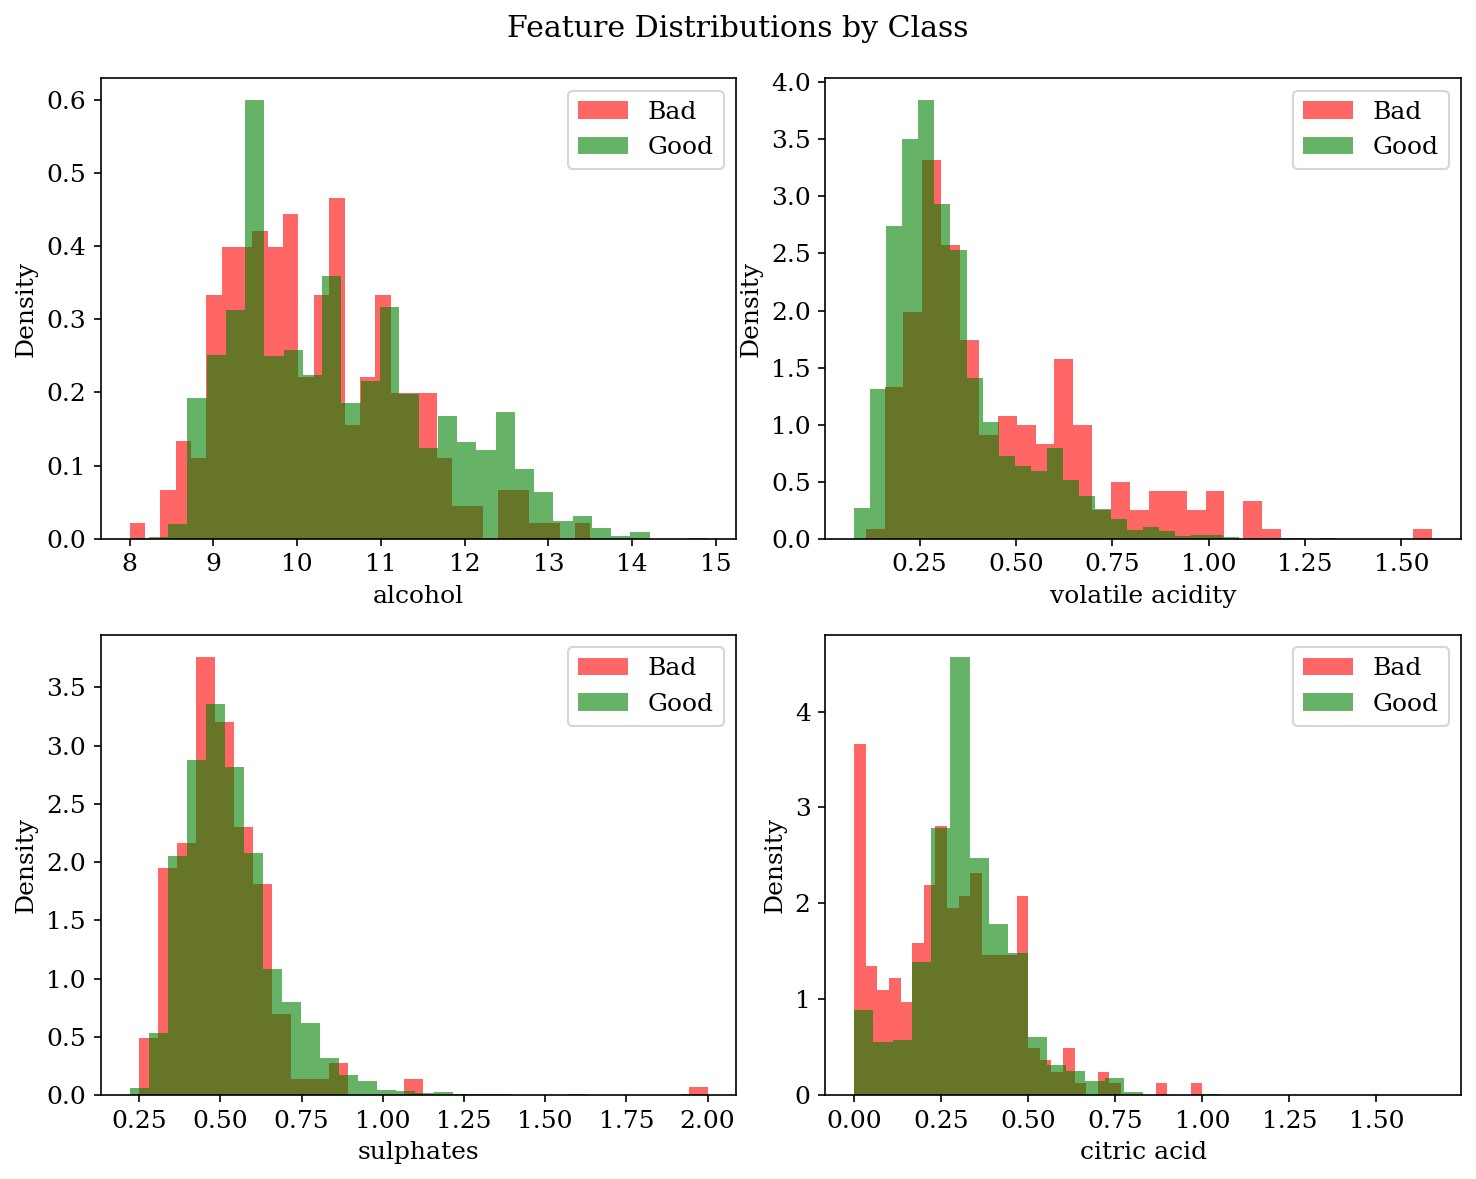

In [7]:
# Feature distributions by class
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for idx, (feat, ax) in enumerate(zip(features, axes.flat)):
    bad_vals = df[df['label']==0][feat].values
    good_vals = df[df['label']==1][feat].values
    ax.hist(bad_vals, bins=30, alpha=0.6, color='red', label='Bad', density=True)
    ax.hist(good_vals, bins=30, alpha=0.6, color='green', label='Good', density=True)
    ax.set_xlabel(feat)
    ax.set_ylabel('Density')
    ax.legend()
plt.suptitle('Feature Distributions by Class')
plt.tight_layout()
plt.show()

## Train/Test Split

In [8]:
np.random.seed(42)
indices = np.random.permutation(len(X))
split = int(0.8 * len(X))
train_idx, test_idx = indices[:split], indices[split:]
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"Train class dist: Bad={sum(y_train==0)}, Good={sum(y_train==1)}")
print(f"Test class dist: Bad={sum(y_test==0)}, Good={sum(y_test==1)}")

Train: 5197, Test: 1300
Train class dist: Bad=195, Good=5002
Test class dist: Bad=51, Good=1249


---
## Task 1: Quadratic Discriminant Analysis (from scratch)

QDA assumes each class follows a multivariate Gaussian with its own mean vector and covariance matrix. The discriminant function for class $c$ is:

$$g_c(\mathbf{x}) = -\frac{1}{2} \ln|\hat{\Sigma}_c| - \frac{1}{2}(\mathbf{x} - \hat{\boldsymbol{\mu}}_c)^T \hat{\Sigma}_c^{-1} (\mathbf{x} - \hat{\boldsymbol{\mu}}_c) + \ln P(c)$$

### Step 1: Estimate Class Parameters (MLE)

In [9]:
# Separate training data by class
X0 = X_train[y_train == 0]  # bad wines
X1 = X_train[y_train == 1]  # good wines
n0, n1 = len(X0), len(X1)
n_train = len(y_train)

# Prior probabilities (class frequencies)
prior_0 = n0 / n_train
prior_1 = n1 / n_train
print(f"Prior P(bad)  = {n0}/{n_train} = {prior_0:.4f}")
print(f"Prior P(good) = {n1}/{n_train} = {prior_1:.4f}")

Prior P(bad)  = 195/5197 = 0.0375
Prior P(good) = 5002/5197 = 0.9625


In [10]:
# MLE mean vectors
mu_0 = np.mean(X0, axis=0)
mu_1 = np.mean(X1, axis=0)

print("MLE Mean vector (bad):")
for f, m in zip(features, mu_0):
    print(f"  {f}: {m:.4f}")

print("\nMLE Mean vector (good):")
for f, m in zip(features, mu_1):
    print(f"  {f}: {m:.4f}")

MLE Mean vector (bad):
  alcohol: 10.1513
  volatile acidity: 0.4591
  sulphates: 0.5092
  citric acid: 0.2728

MLE Mean vector (good):
  alcohol: 10.4997
  volatile acidity: 0.3364
  sulphates: 0.5343
  citric acid: 0.3201


In [11]:
# MLE covariance matrices (using 1/N, not 1/(N-1))
cov_0 = np.cov(X0.T, bias=True)
cov_1 = np.cov(X1.T, bias=True)

print("MLE Covariance matrix (bad):")
print(np.array2string(cov_0, precision=4, suppress_small=True))
print("\nMLE Covariance matrix (good):")
print(np.array2string(cov_1, precision=4, suppress_small=True))

print("\nNote: The covariance matrices are clearly different between classes,")
print("which is why QDA (separate covariances) is more appropriate than LDA (shared covariance).")

MLE Covariance matrix (bad):
[[ 0.9896  0.0081 -0.0128 -0.018 ]
 [ 0.0081  0.059   0.0043 -0.0192]
 [-0.0128  0.0043  0.0267  0.007 ]
 [-0.018  -0.0192  0.007   0.032 ]]

MLE Covariance matrix (good):
[[ 1.4334 -0.0084 -0.0037 -0.0043]
 [-0.0084  0.0252  0.0059 -0.0084]
 [-0.0037  0.0059  0.0227  0.001 ]
 [-0.0043 -0.0084  0.001   0.0203]]

Note: The covariance matrices are clearly different between classes,
which is why QDA (separate covariances) is more appropriate than LDA (shared covariance).


### Step 2: Build the QDA Classifier

In [12]:
def qda_discriminant(x, mu, cov, prior):
    """
    Compute the QDA discriminant function for a single sample.
    
    g(x) = -0.5 * ln|Sigma| - 0.5 * (x-mu)^T Sigma^{-1} (x-mu) + ln(P(class))
    """
    diff = x - mu
    cov_inv = np.linalg.inv(cov)
    log_det = np.log(np.linalg.det(cov))
    return -0.5 * log_det - 0.5 * diff @ cov_inv @ diff + np.log(prior)


def qda_classify(X, mu_0, cov_0, prior_0, mu_1, cov_1, prior_1):
    """
    Classify samples using QDA.
    Assigns the class with the highest discriminant score.
    """
    y_pred = []
    for x in X:
        g0 = qda_discriminant(x, mu_0, cov_0, prior_0)
        g1 = qda_discriminant(x, mu_1, cov_1, prior_1)
        y_pred.append(0 if g0 > g1 else 1)
    return np.array(y_pred)

### Step 3: Train and Test

In [13]:
# Predict on test set
y_pred_qda = qda_classify(X_test, mu_0, cov_0, prior_0, mu_1, cov_1, prior_1)

# Accuracy
acc_qda = np.mean(y_pred_qda == y_test)
print(f"QDA Test Accuracy: {acc_qda:.4f}")

QDA Test Accuracy: 0.9562


### Step 4: Performance Evaluation

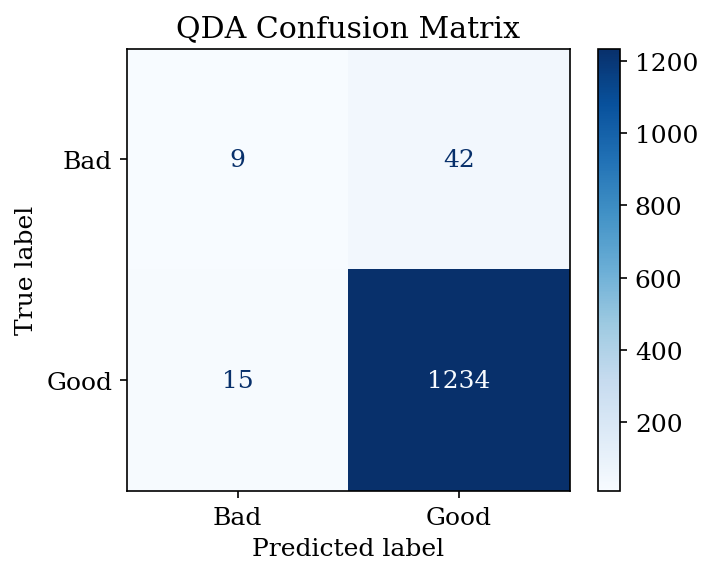


Classification Report:
              precision    recall  f1-score   support

         Bad       0.38      0.18      0.24        51
        Good       0.97      0.99      0.98      1249

    accuracy                           0.96      1300
   macro avg       0.67      0.58      0.61      1300
weighted avg       0.94      0.96      0.95      1300



In [14]:
# Confusion matrix
cm_qda = confusion_matrix(y_test, y_pred_qda)
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(cm_qda, display_labels=['Bad', 'Good'])
disp.plot(ax=ax, cmap='Blues')
ax.set_title('QDA Confusion Matrix')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_qda, target_names=['Bad', 'Good']))

The accuracy looks high (95.6%), but thats mostly because the dataset is so imbalanced. Looking at the per-class metrics, QDA only catches 18% of the bad wines. The prior heavily favors "good", so the classifier is biased toward that class.

---
## Task 2: $k$-Nearest Neighbors Classifier (from scratch)

kNN is a non-parametric classifier. It doesn't assume any distribution --- it just looks at the $k$ closest training samples and takes a majority vote.

### Step 1: Standardize Features

kNN is distance-based, so features need to be on the same scale. Without standardization, alcohol (range ~8-15) would dominate over sulphates (range ~0.2-2.0).

In [15]:
# Standardize using training set statistics only
mean_train = np.mean(X_train, axis=0)
std_train = np.std(X_train, axis=0)

X_train_std = (X_train - mean_train) / std_train
X_test_std = (X_test - mean_train) / std_train  # use train stats!

print("Feature means (train, before standardization):", mean_train.round(4))
print("Feature stds (train, before standardization):", std_train.round(4))
print("\nAfter standardization, means:", X_train_std.mean(axis=0).round(6))
print("After standardization, stds:", X_train_std.std(axis=0).round(6))

Feature means (train, before standardization): [10.4866  0.341   0.5334  0.3183]
Feature stds (train, before standardization): [1.1921 0.1643 0.1513 0.1444]

After standardization, means: [-0. -0. -0.  0.]
After standardization, stds: [1. 1. 1. 1.]


### Step 2: Build the kNN Classifier

In [16]:
def knn_predict(X_train, y_train, X_test, k):
    """
    k-Nearest Neighbors classifier using Euclidean distance.
    Vectorized implementation for speed.
    
    Uses the identity: ||a-b||^2 = ||a||^2 + ||b||^2 - 2*a.b
    to compute all pairwise distances at once.
    """
    # Compute squared distances efficiently
    train_sq = np.sum(X_train**2, axis=1)   # (n_train,)
    test_sq = np.sum(X_test**2, axis=1)     # (n_test,)
    cross = X_test @ X_train.T              # (n_test, n_train)
    dists = np.sqrt(np.maximum(test_sq[:, None] + train_sq[None, :] - 2*cross, 0))
    
    # For each test sample, find the k nearest neighbors
    nearest_idx = np.argpartition(dists, k, axis=1)[:, :k]
    
    # Majority vote
    y_pred = []
    for i in range(len(X_test)):
        nearest_labels = y_train[nearest_idx[i]]
        counts = np.bincount(nearest_labels)
        y_pred.append(np.argmax(counts))
    
    return np.array(y_pred)

### Step 3: Select $k$

In [17]:
# Test different k values
ks = [1, 3, 5, 7, 9, 11, 15, 21, 31]
accs = []

print("k-value search:")
for k in ks:
    yp = knn_predict(X_train_std, y_train, X_test_std, k)
    acc = np.mean(yp == y_test)
    accs.append(acc)
    cm = confusion_matrix(y_test, yp)
    bad_recall = cm[0,0] / cm[0].sum() if cm[0].sum() > 0 else 0
    print(f"  k={k:2d}: Accuracy={acc:.4f}, Bad Recall={bad_recall:.4f}")

k-value search:


  k= 1: Accuracy=0.9354, Bad Recall=0.2353


  k= 3: Accuracy=0.9531, Bad Recall=0.0784


  k= 5: Accuracy=0.9600, Bad Recall=0.0588


  k= 7: Accuracy=0.9608, Bad Recall=0.0392


  k= 9: Accuracy=0.9585, Bad Recall=0.0000


  k=11: Accuracy=0.9600, Bad Recall=0.0196


  k=15: Accuracy=0.9600, Bad Recall=0.0196


  k=21: Accuracy=0.9608, Bad Recall=0.0000


  k=31: Accuracy=0.9608, Bad Recall=0.0000


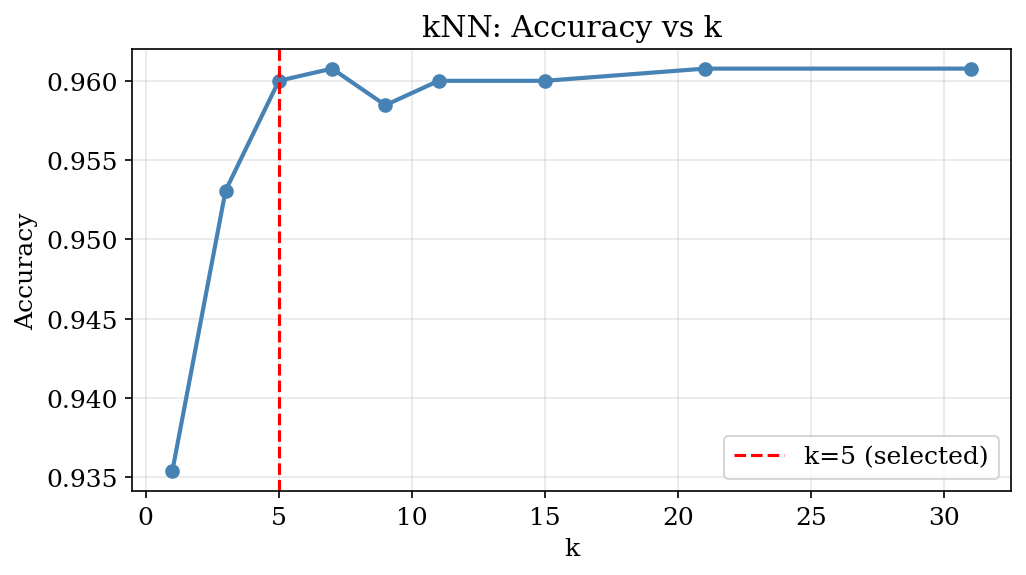

In [18]:
# Plot accuracy vs k
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ks, accs, 'o-', color='steelblue', linewidth=2, markersize=6)
ax.set_xlabel('k')
ax.set_ylabel('Accuracy')
ax.set_title('kNN: Accuracy vs k')
ax.axvline(x=5, color='red', linestyle='--', label='k=5 (selected)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

I picked **k=5**. Accuracy stabilizes around k=5-7. Smaller values (k=1, k=3) are more prone to overfitting. Going much higher just makes the classifier default to the majority class even more.

### Step 4: Train and Test

In [19]:
k_val = 5
y_pred_knn = knn_predict(X_train_std, y_train, X_test_std, k_val)

acc_knn = np.mean(y_pred_knn == y_test)
print(f"kNN (k={k_val}) Test Accuracy: {acc_knn:.4f}")

kNN (k=5) Test Accuracy: 0.9600


### Step 5: Performance Evaluation

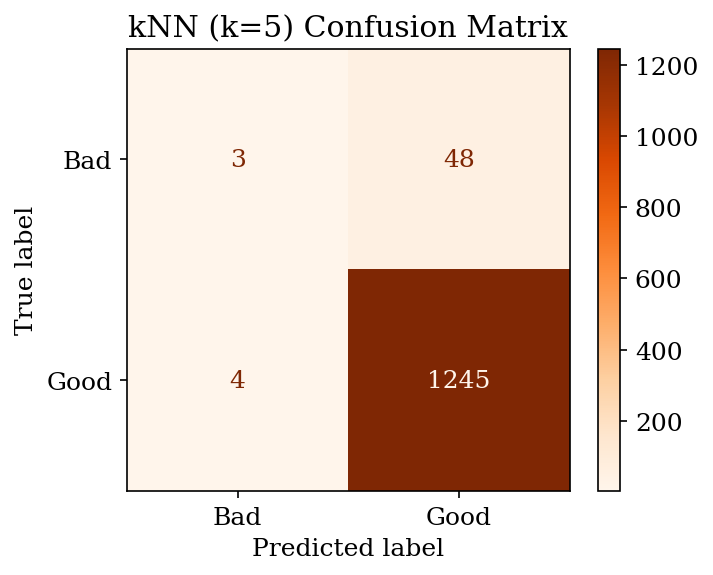


Classification Report:
              precision    recall  f1-score   support

         Bad       0.43      0.06      0.10        51
        Good       0.96      1.00      0.98      1249

    accuracy                           0.96      1300
   macro avg       0.70      0.53      0.54      1300
weighted avg       0.94      0.96      0.95      1300



In [20]:
# Confusion matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(cm_knn, display_labels=['Bad', 'Good'])
disp.plot(ax=ax, cmap='Oranges')
ax.set_title(f'kNN (k={k_val}) Confusion Matrix')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn, target_names=['Bad', 'Good']))

### Step 6: Without Standardization (for comparison)

In [21]:
# kNN without standardization to show why it matters
y_pred_nostd = knn_predict(X_train, y_train, X_test, k_val)
acc_nostd = np.mean(y_pred_nostd == y_test)
print(f"kNN (k={k_val}) WITHOUT standardization: Accuracy = {acc_nostd:.4f}")
print(f"kNN (k={k_val}) WITH standardization:    Accuracy = {acc_knn:.4f}")
print(f"\nStandardization helps because features have very different scales.")

kNN (k=5) WITHOUT standardization: Accuracy = 0.9592
kNN (k=5) WITH standardization:    Accuracy = 0.9600

Standardization helps because features have very different scales.


---
## Comparison: QDA vs kNN

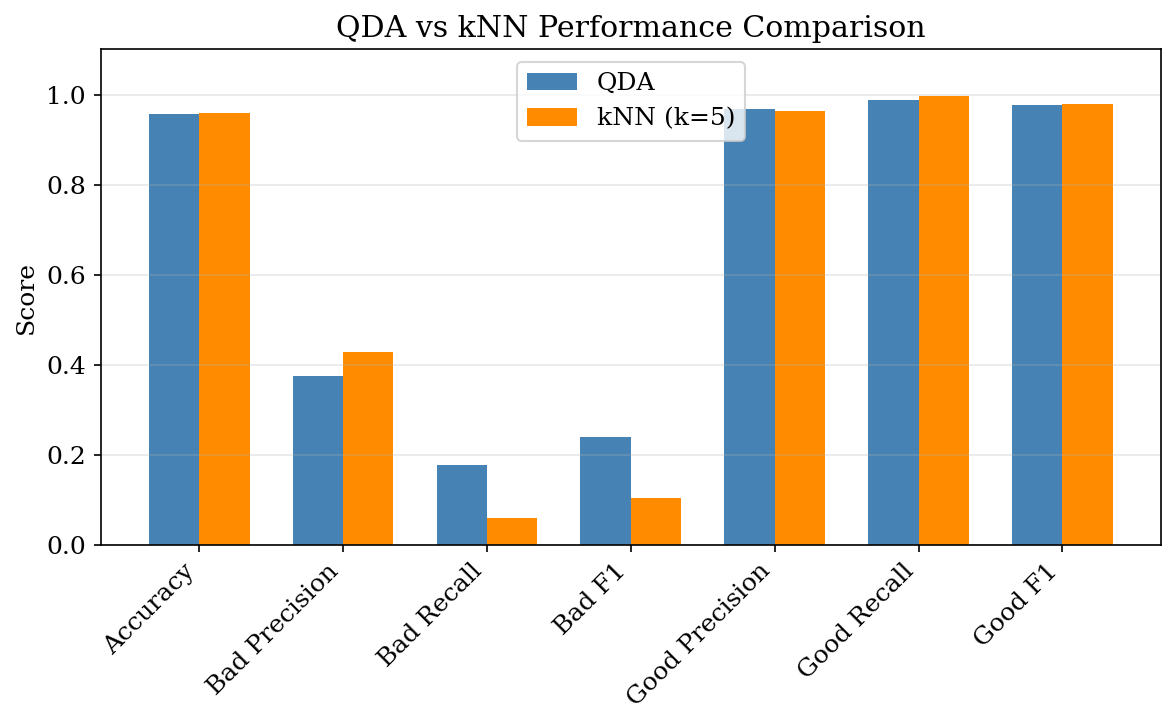

In [22]:
# Side-by-side comparison
p_qda, r_qda, f_qda, _ = precision_recall_fscore_support(y_test, y_pred_qda, labels=[0,1])
p_knn, r_knn, f_knn, _ = precision_recall_fscore_support(y_test, y_pred_knn, labels=[0,1])

metrics = ['Accuracy', 'Bad Precision', 'Bad Recall', 'Bad F1', 'Good Precision', 'Good Recall', 'Good F1']
qda_vals = [acc_qda, p_qda[0], r_qda[0], f_qda[0], p_qda[1], r_qda[1], f_qda[1]]
knn_vals = [acc_knn, p_knn[0], r_knn[0], f_knn[0], p_knn[1], r_knn[1], f_knn[1]]

fig, ax = plt.subplots(figsize=(8, 5))
x_pos = np.arange(len(metrics))
width = 0.35
ax.bar(x_pos - width/2, qda_vals, width, label='QDA', color='steelblue')
ax.bar(x_pos + width/2, knn_vals, width, label=f'kNN (k={k_val})', color='darkorange')
ax.set_xticks(x_pos)
ax.set_xticklabels(metrics, rotation=45, ha='right')
ax.set_ylabel('Score')
ax.set_title('QDA vs kNN Performance Comparison')
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
# Summary table
print(f"{'Metric':<20} {'QDA':>10} {'kNN (k='+str(k_val)+')':>12}")
print("-" * 44)
for m, q, k in zip(metrics, qda_vals, knn_vals):
    print(f"{m:<20} {q:>10.4f} {k:>12.4f}")

print("\n--- Key Takeaways ---")
print("1. Both classifiers achieve ~96% accuracy, but thats misleading due to class imbalance")
print("2. QDA is better at detecting bad wines (recall 0.18 vs 0.06)")
print("3. kNN defaults to majority class because most neighbors are 'good'")
print("4. Neither classifier handles the imbalance well without additional techniques")

Metric                      QDA    kNN (k=5)
--------------------------------------------
Accuracy                 0.9562       0.9600
Bad Precision            0.3750       0.4286
Bad Recall               0.1765       0.0588
Bad F1                   0.2400       0.1034
Good Precision           0.9671       0.9629
Good Recall              0.9880       0.9968
Good F1                  0.9774       0.9795

--- Key Takeaways ---
1. Both classifiers achieve ~96% accuracy, but thats misleading due to class imbalance
2. QDA is better at detecting bad wines (recall 0.18 vs 0.06)
3. kNN defaults to majority class because most neighbors are 'good'
4. Neither classifier handles the imbalance well without additional techniques
